In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Challenge-1-Student-Performance',
 'Challenge-2-Marketing-Campaign',
 'Untitled.ipynb']

In [4]:
df = pd.read_csv("Challenge-2-Marketing-Campaign/superstore_data.csv")
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,...,11,0,34,2,3,1,2,7,1,0


In [5]:
df.isnull().sum()

Id                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Response                0
Complain                0
dtype: int64

In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()

Id                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Response               0
Complain               0
dtype: int64

In [9]:
df["Age"] = 2024 - df["Year_Birth"]

In [10]:
df["Age"] = 2024 - df["Year_Birth"]
df[["Year_Birth","Age"]].head()

,Year_Birth,Age
0,1970,54
1,1961,63
2,1958,66
3,1967,57
4,1989,35


In [11]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])

In [12]:
df["Dt_Customer"].head()

0   2014-06-16
1   2014-06-15
2   2014-05-13
3   2014-11-05
4   2014-08-04
Name: Dt_Customer, dtype: datetime64[us]

In [13]:
df["Customer_Since_Years"] = 2024 - df["Dt_Customer"].dt.year

In [14]:
df[["Dt_Customer","Customer_Since_Years"]].head()

,Dt_Customer,Customer_Since_Years
0,2014-06-16,10
1,2014-06-15,10
2,2014-05-13,10
3,2014-11-05,10
4,2014-08-04,10


In [15]:
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

In [16]:
df[["Total_Spending"]].head()

,Total_Spending
0,1190
1,577
2,251
3,11
4,91


In [17]:
df["Children"] = df["Kidhome"] + df["Teenhome"]

In [18]:
df[["Kidhome","Teenhome","Children"]].head()

,Kidhome,Teenhome,Children
0,0,0,0
1,0,0,0
2,0,1,1
3,1,1,2
4,1,0,1


In [19]:
df["Response"].mean()

np.float64(0.14910714285714285)

In [20]:
df.groupby("Response")["Income"].mean()

Response
0    50845.677597
1    60183.244012
Name: Income, dtype: float64

In [21]:
df.groupby("Response")[[
    "MntWines",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]].mean()

,MntWines,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Response,,,,,
0,269.104407,144.624344,34.980063,25.035152,40.968520
1,502.703593,294.353293,52.050898,38.634731,61.446108


In [22]:
df.groupby("Education")["Response"].mean()

Education
2n Cycle      0.108374
Basic         0.037037
Graduation    0.134871
Master        0.154054
PhD           0.207819
Name: Response, dtype: float64

In [23]:
df.groupby("Marital_Status")["Response"].mean()

Marital_Status
Absurd      0.500000
Alone       0.333333
Divorced    0.206897
Married     0.113426
Single      0.220833
Together    0.103448
Widow       0.246753
YOLO        0.500000
Name: Response, dtype: float64

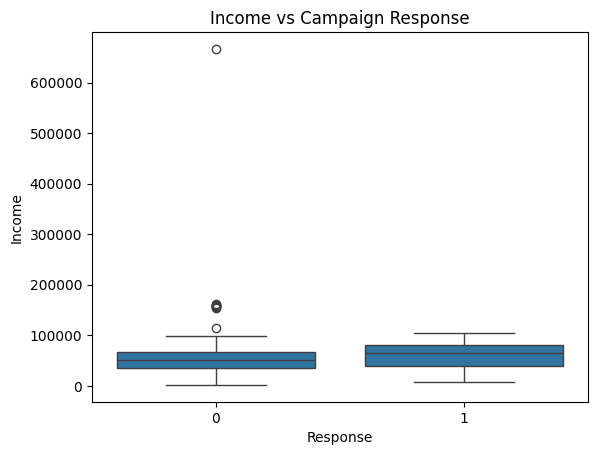

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Response", y="Income", data=df)
plt.title("Income vs Campaign Response")
plt.show()

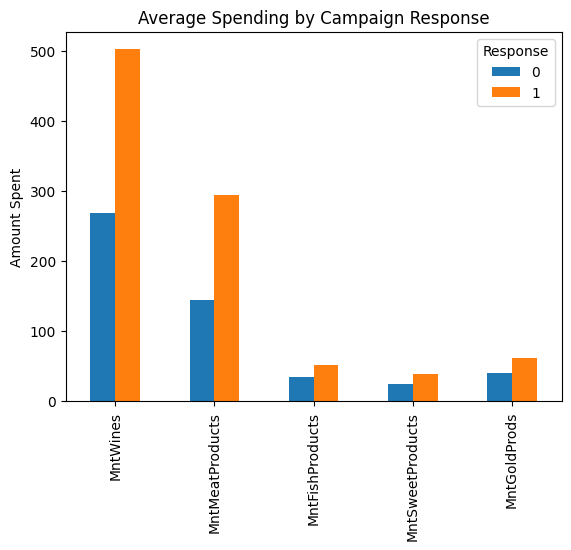

In [25]:
spend_cols = [
    "MntWines",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df.groupby("Response")[spend_cols].mean().T.plot(kind="bar")
plt.title("Average Spending by Campaign Response")
plt.ylabel("Amount Spent")
plt.show()

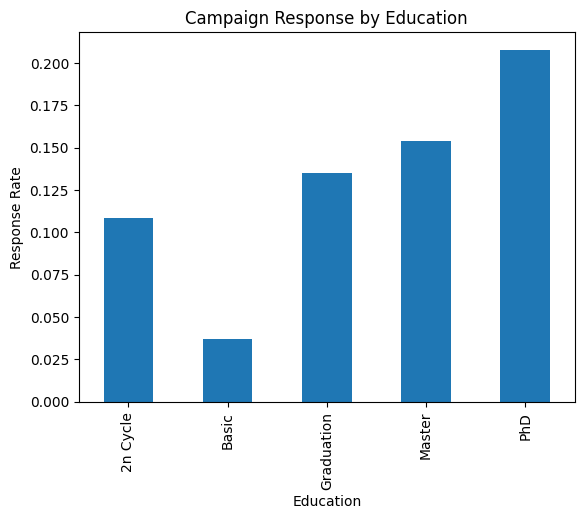

In [26]:
df.groupby("Education")["Response"].mean().plot(kind="bar")
plt.title("Campaign Response by Education")
plt.ylabel("Response Rate")
plt.show()